# Time-Varying Threshold Experiments

Does the optimal imbalance threshold change over the course of the minute?

**Three approaches tested:**
1. **Fixed** (baseline) — single `theta_imb`, constant all minute
2. **Two-Window** — separate thresholds for first/second 30s, fit greedily
3. **Slope** — `theta(t) = theta_imb + slope * (t/60)`, slope can be positive or negative

In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.config import DEFAULT_CONFIG
from utils.strategy import OIThresholdStrategy, TwoWindowStrategy, SlopeStrategy, run_experiment
from utils.evaluation import print_results, plot_results, compare_strategies

config = DEFAULT_CONFIG.copy()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run All Three Strategies

In [4]:
# Shared cache: avoids redundant data loading and base fits
cache = {}

baseline = run_experiment(OIThresholdStrategy, config, _shared=cache)
print()
two_window = run_experiment(TwoWindowStrategy, config, _shared=cache)
print()
slope = run_experiment(SlopeStrategy, config, _shared=cache)

Running experiment: OI Threshold (signal=oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
  Done.
    penny: theta_imb=0.9500, theta_spread=0.0116
    wide: theta_imb=0.5200, theta_spread=0.1566
  Backtesting...

Running experiment: Two-Window (signal=oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
  Done.
    penny: theta_imb_w1=0.9500, theta_imb_w2=0.9500, theta_spread=0.0116
    wide: theta_imb_w1=0.5497, theta_imb_w2=0.5645, theta_spread=0.1566
  Backtesting...

Running experiment: Slope (signal=oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
  Done.
    penny: theta_imb=0.9500, slope=0.0000, theta_spread=0.0116
    wide: theta_imb=0.5648, slope=-0.4000, theta_spread=0.1566
  Backtesting...


## Comparison

STRATEGY COMPARISON

  Penny:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    Fixed Threshold                +0.5634       0.5791      77.2%
    Two-Window                     +0.5634       0.5791      77.2%
    Slope                          +0.5634       0.5791      77.2%

  Wide:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    Fixed Threshold                +0.2493       0.6677      62.3%
    Two-Window                     +0.2482       0.6678      62.7%
    Slope                          +0.2242       0.6768      59.9%

  All:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    Fixed Threshold                +0.5058       1.7226      69.8%
    Two-Window                     +0.5038       1.7223      69.9%
    Slope      

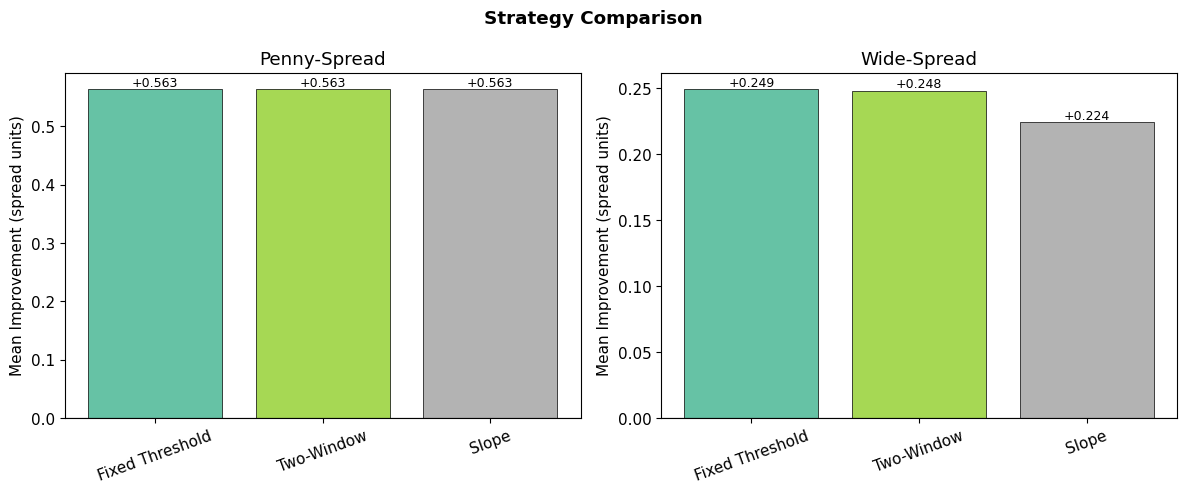

In [5]:
comparison = compare_strategies([
    ('Fixed Threshold', baseline),
    ('Two-Window', two_window),
    ('Slope', slope),
])

## Slope Strategy Details

In [6]:
print_results(slope['test_all'], strategy_name='Slope')

# Show fitted slope values
print("\nFitted parameters:")
print(f"{'':6s} {'theta_imb':>12s} {'slope':>10s} {'theta_spread':>14s}")
print(f"{'':6s} {'─'*12} {'─'*10} {'─'*14}")
for arch in ['penny', 'wide']:
    p = slope['fitted'][arch]
    base_p = baseline['fitted'][arch]
    print(f"  {arch.title():6s} {p['theta_imb']:12.4f} {p['slope']:+10.4f} {p['theta_spread']:14.4f}  "
          f"(fixed baseline: {base_p['theta_imb']:.4f})")
    # Show what the threshold looks like at t=0, 30, 60
    for t in [0, 30, 60]:
        th = max(0, min(1, p['theta_imb'] + p['slope'] * (t / 60.0)))
        print(f"{'':10s} t={t:2d}s → threshold = {th:.4f}")

Mean Improvement over TWAP ($)
  Penny  (n= 324, win_rate=77.2%)  Slope: $+0.005634  First Tick: $+0.000695  Last Tick: $+0.000695
  Wide   (n= 324, win_rate=59.9%)  Slope: $+0.035878  First Tick: $+0.004427  Last Tick: $+0.004828
  All    (n= 648, win_rate=68.5%)  Slope: $+0.020756  First Tick: $+0.002561  Last Tick: $+0.002762

Mean Improvement (spread units)

  Penny (median spread = $0.0100):
    Slope               : +0.5634 spread units
    First Tick          : +0.0695 spread units
    Last Tick           : +0.0695 spread units

  Wide (median spread = $0.1600):
    Slope               : +0.2242 spread units
    First Tick          : +0.0277 spread units
    Last Tick           : +0.0302 spread units

Fitted parameters:
          theta_imb      slope   theta_spread
       ──────────── ────────── ──────────────
  Penny        0.9500    +0.0000         0.0116  (fixed baseline: 0.9500)
           t= 0s → threshold = 0.9500
           t=30s → threshold = 0.9500
           t=60s → th